# VC Fund Optimizer — Finding the Best Check Size & Fund Size

Systematically searches the full parameter space across two axes:

| Axis | Range | Values |
|------|-------|--------|
| Fund size | $75M → $300M | 8 levels |
| Avg initial check | $0.75M → $7.5M | 8 levels |

For each of the 64 combinations, the number of portfolio companies is **derived**
from the fund size and check size (so check size determines portfolio depth, not just
check size in isolation). All 64 scenarios run in parallel via `ThreadPoolExecutor`,
500 Monte Carlo trials each (32,000 total runs).

**Objective functions:**
- *Median gross IRR* — central return expectation
- *P10 gross IRR* — downside floor (what happens in a bad vintage)
- *Risk-adjusted score* = 0.6 × Median IRR + 0.4 × P10 IRR
- *DPI* — multiple on committed capital

> Fixed assumptions: AI seed entry $27.5M post-money · 40% reserve · 90% deployment rate · 2026 exit distribution


## 1 — Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.optimize import brentq
from dataclasses import dataclass
from typing import List
from copy import deepcopy
from concurrent.futures import ThreadPoolExecutor, as_completed
import time
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 110})
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("tab10")
pd.options.display.float_format = '{:,.2f}'.format

# ── Optimization grid ─────────────────────────────────────────────────────────
FUND_SIZES   = [75, 100, 125, 150, 175, 200, 250, 300]   # $M
AVG_CHECKS   = [0.75, 1.00, 1.50, 2.00, 2.50, 3.00, 4.50, 7.50]  # $M avg initial check
# Calibrated to base case of 25-30 companies ($140M fund → avg $2.8M check)
# Range covers: spray & pray ($0.75-1M → 50+ cos) through ultra-conviction ($7.5M → ~10 cos)

# Fixed
ENTRY_POST_MONEY_M = 27.5
RESERVE_RATIO      = 0.40
DEPLOYMENT_RATE    = 0.90
DILUTION_PER_ROUND = 0.22
N_SIMS             = 500

# Risk-adjusted score weights
W_MEDIAN = 0.60
W_P10    = 0.40

print(f"Grid: {len(FUND_SIZES)} fund sizes × {len(AVG_CHECKS)} check sizes = "
      f"{len(FUND_SIZES)*len(AVG_CHECKS)} combinations")
print(f"Total MC runs: {len(FUND_SIZES)*len(AVG_CHECKS)*N_SIMS:,}")
print()
print(f"Fund sizes:   {FUND_SIZES}")
print(f"Avg checks:   {AVG_CHECKS}")
print(f"Entry val:    ${ENTRY_POST_MONEY_M}M post-money  (fixed)")
print(f"Reserve:      {RESERVE_RATIO:.0%}  |  Deployment: {DEPLOYMENT_RATE:.0%}")


Grid: 8 fund sizes × 8 check sizes = 64 combinations
Total MC runs: 32,000

Fund sizes:   [75, 100, 125, 150, 175, 200, 250, 300]
Avg checks:   [0.75, 1.0, 1.5, 2.0, 2.5, 3.0, 4.5, 7.5]
Entry val:    $27.5M post-money  (fixed)
Reserve:      40%  |  Deployment: 90%


## 2 — Model Functions

In [2]:
@dataclass
class OutcomeBucket:
    label: str
    prob: float
    exit_val_lo_m: float
    exit_val_hi_m: float
    avg_dilutive_rounds: float

@dataclass
class FundConfig:
    name: str
    fund_size_m: float
    vintage_year: int
    entry_post_money_m: float
    dilution_per_round: float
    deployment_rate: float
    num_investments: int
    reserve_ratio: float
    check_min_m: float
    check_max_m: float
    follow_on_pct: float
    outcome_buckets: List[OutcomeBucket]
    avg_hold_yrs: float
    std_hold_yrs: float
    fund_life_yrs: int  = 10
    invest_period_yrs: int = 5


# 2026 AI seed exit distribution
AI_SEED_BUCKETS = [
    OutcomeBucket('Total Loss',   0.17,    0.0,     0.0,  0.0),
    OutcomeBucket('Small Return', 0.31,    2.0,    50.0,  0.5),
    OutcomeBucket('Mid Return',   0.27,   50.0,   400.0,  2.0),
    OutcomeBucket('Outsize',      0.13,  400.0,  2000.0,  3.0),
    OutcomeBucket('Outlier',      0.06, 2000.0, 10000.0,  4.0),
]


def simulate_portfolio(cfg: FundConfig, seed: int = None) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    n = cfg.num_investments

    deployed    = cfg.fund_size_m * cfg.deployment_rate
    initial_cap = deployed * (1 - cfg.reserve_ratio)
    reserve_cap = deployed * cfg.reserve_ratio
    n_fo        = max(1, int(n * cfg.follow_on_pct))

    probs = np.array([b.prob for b in cfg.outcome_buckets], dtype=float)
    probs /= probs.sum()
    bucket_idx = rng.choice(len(cfg.outcome_buckets), size=n, p=probs)

    raw = np.exp(rng.uniform(np.log(cfg.check_min_m), np.log(cfg.check_max_m), size=n))
    initial_checks = raw / raw.sum() * initial_cap

    follow_on = np.zeros(n)
    bucket_rank  = np.array([b.exit_val_hi_m for b in cfg.outcome_buckets])
    company_rank = bucket_rank[bucket_idx] + rng.uniform(0, 1, n)
    fo_idx = np.argsort(company_rank)[::-1][:n_fo]
    raw_fo = rng.uniform(0.5, 2.0, size=n_fo)
    follow_on[fo_idx] = raw_fo / raw_fo.sum() * reserve_cap

    total_invested = initial_checks + follow_on

    exit_vals  = np.zeros(n)
    rounds_arr = np.zeros(n)
    for i, bi in enumerate(bucket_idx):
        b = cfg.outcome_buckets[bi]
        if b.exit_val_hi_m == 0:
            exit_vals[i] = rounds_arr[i] = 0.0
        else:
            lo = max(b.exit_val_lo_m, 0.1)
            exit_vals[i]  = np.exp(rng.uniform(np.log(lo), np.log(b.exit_val_hi_m)))
            rounds_arr[i] = max(0.0, rng.normal(b.avg_dilutive_rounds, 0.5))

    initial_ownership = initial_checks / cfg.entry_post_money_m
    diluted_ownership = initial_ownership * (1 - cfg.dilution_per_round) ** rounds_arr
    gross_proceeds    = diluted_ownership * exit_vals

    inv_yr  = rng.uniform(0.5, float(cfg.invest_period_yrs), size=n)
    hold    = np.clip(rng.normal(cfg.avg_hold_yrs, cfg.std_hold_yrs, size=n),
                      2.0, float(cfg.fund_life_yrs - 1))
    exit_yr = np.clip(inv_yr + hold, 1.0, float(cfg.fund_life_yrs))

    return pd.DataFrame(dict(
        inv_year=inv_yr, exit_year=exit_yr,
        initial_check=initial_checks, follow_on=follow_on,
        total_invested=total_invested, gross_proceeds=gross_proceeds,
    ))


def build_cashflows(cfg: FundConfig, portfolio: pd.DataFrame) -> pd.DataFrame:
    yrs      = np.arange(cfg.fund_life_yrs + 1, dtype=float)
    invested = np.zeros(len(yrs))
    proceeds = np.zeros(len(yrs))
    undepl   = np.zeros(len(yrs))

    for _, row in portfolio.iterrows():
        yr = int(min(row['inv_year'], cfg.invest_period_yrs))
        invested[yr] += row['initial_check']
        if row['follow_on'] > 0:
            fo_yr = int(min(yr + 2, cfg.fund_life_yrs))
            invested[fo_yr] += row['follow_on']
    for _, row in portfolio.iterrows():
        yr = int(min(row['exit_year'], cfg.fund_life_yrs))
        proceeds[yr] += row['gross_proceeds']

    undeployed = cfg.fund_size_m * (1 - cfg.deployment_rate)
    proceeds[cfg.fund_life_yrs] += undeployed
    undepl[cfg.fund_life_yrs]    = undeployed
    return pd.DataFrame(dict(year=yrs, invested=invested, gross_proceeds=proceeds,
                             undeployed_returned=undepl))


def calc_irr(cashflows: np.ndarray) -> float:
    t = np.arange(len(cashflows), dtype=float)
    def npv(r): return np.sum(cashflows / (1 + r) ** t)
    try:    return brentq(npv, -0.9999, 20.0, maxiter=500)
    except: return np.nan


def monte_carlo(cfg: FundConfig, n_sims: int = 500) -> pd.DataFrame:
    undeployed = cfg.fund_size_m * (1 - cfg.deployment_rate)
    deployed   = cfg.fund_size_m * cfg.deployment_rate
    rows = []
    for s in range(n_sims):
        port  = simulate_portfolio(cfg, seed=s)
        cf    = build_cashflows(cfg, port)
        gross = cf['gross_proceeds'].sum() - undeployed
        total_proceeds = gross + undeployed
        gross_cf = (-cf['invested'] + (cf['gross_proceeds'] - cf['undeployed_returned'])).values
        rows.append(dict(
            gross_moic    = gross / deployed if deployed > 0 else np.nan,
            total_moic    = total_proceeds / cfg.fund_size_m,
            dpi           = total_proceeds / cfg.fund_size_m,
            gross_irr_pct = calc_irr(gross_cf) * 100,
        ))
    return pd.DataFrame(rows)


print("Model functions loaded.")


Model functions loaded.


## 3 — Build Configuration Grid

In [3]:
def make_config(fund_size_m: float, avg_check_m: float) -> FundConfig | None:
    deployed    = fund_size_m * DEPLOYMENT_RATE
    initial_cap = deployed * (1 - RESERVE_RATIO)
    n = int(round(initial_cap / avg_check_m))
    if n < 8 or n > 200:
        return None   # impractical

    # Check range: ±50% around avg (log-uniform draw will still average to avg_check_m)
    chk_lo = max(0.10, avg_check_m * 0.50)
    chk_hi = avg_check_m * 1.50

    return FundConfig(
        name             = f"F{fund_size_m:.0f}_C{avg_check_m:.2f}",
        fund_size_m      = fund_size_m,
        vintage_year     = 2026,
        entry_post_money_m = ENTRY_POST_MONEY_M,
        dilution_per_round = DILUTION_PER_ROUND,
        deployment_rate  = DEPLOYMENT_RATE,
        num_investments  = n,
        reserve_ratio    = RESERVE_RATIO,
        check_min_m      = chk_lo,
        check_max_m      = chk_hi,
        follow_on_pct    = 0.45,
        outcome_buckets  = AI_SEED_BUCKETS,
        avg_hold_yrs     = 7.0,
        std_hold_yrs     = 1.5,
    )


# Build grid, skip infeasible cells
grid = {}
skipped = []
for fs in FUND_SIZES:
    for ac in AVG_CHECKS:
        cfg = make_config(fs, ac)
        if cfg is not None:
            grid[(fs, ac)] = cfg
        else:
            skipped.append((fs, ac))

print(f"Valid combinations: {len(grid)}  (skipped {len(skipped)} infeasible)")
print()

# Preview: derived # of investments per cell
n_inv_table = pd.DataFrame(index=[f"${fs}M" for fs in FUND_SIZES],
                            columns=[f"${ac}M" for ac in AVG_CHECKS])
for fs in FUND_SIZES:
    for ac in AVG_CHECKS:
        key = (fs, ac)
        if key in grid:
            n_inv_table.loc[f"${fs}M", f"${ac}M"] = grid[key].num_investments
        else:
            n_inv_table.loc[f"${fs}M", f"${ac}M"] = "—"

print("Derived # of portfolio companies per cell:")
print(n_inv_table.to_string())


Valid combinations: 61  (skipped 3 infeasible)

Derived # of portfolio companies per cell:
      $0.75M $1.0M $1.5M $2.0M $2.5M $3.0M $4.5M $7.5M
$75M      54    40    27    20    16    14     9     —
$100M     72    54    36    27    22    18    12     —
$125M     90    68    45    34    27    22    15     9
$150M    108    81    54    40    32    27    18    11
$175M    126    94    63    47    38    32    21    13
$200M    144   108    72    54    43    36    24    14
$250M    180   135    90    68    54    45    30    18
$300M      —   162   108    81    65    54    36    22


## 4 — Parallel Grid Search

In [4]:
def _run(args):
    key, cfg, n_sims = args
    return key, monte_carlo(cfg, n_sims)

t0 = time.time()
results = {}
args_list = [(k, cfg, N_SIMS) for k, cfg in grid.items()]

with ThreadPoolExecutor(max_workers=len(args_list)) as pool:
    futures = {pool.submit(_run, a): a[0] for a in args_list}
    done = 0
    for future in as_completed(futures):
        key, df = future.result()
        results[key] = df
        done += 1
        if done % 8 == 0 or done == len(args_list):
            print(f"  {done}/{len(args_list)} done ...", end="\r")

elapsed = time.time() - t0
print(f"\n{len(results)} scenarios × {N_SIMS} sims = "
      f"{len(results)*N_SIMS:,} total runs  ({elapsed:.1f}s)")


  61/61 done ...
61 scenarios × 500 sims = 30,500 total runs  (29.4s)


## 5 — Results Tables

In [5]:
fund_labels  = [f"${fs}M" for fs in FUND_SIZES]
check_labels = [f"${ac}M" for ac in AVG_CHECKS]

def make_table(metric_fn):
    t = pd.DataFrame(index=fund_labels, columns=check_labels, dtype=float)
    for fs, fl in zip(FUND_SIZES, fund_labels):
        for ac, cl in zip(AVG_CHECKS, check_labels):
            key = (fs, ac)
            if key in results:
                t.loc[fl, cl] = metric_fn(results[key])
            else:
                t.loc[fl, cl] = np.nan
    return t

irr_med  = make_table(lambda df: df['gross_irr_pct'].median())
irr_p10  = make_table(lambda df: df['gross_irr_pct'].quantile(0.10))
irr_p90  = make_table(lambda df: df['gross_irr_pct'].quantile(0.90))
dpi_med  = make_table(lambda df: df['dpi'].median())
moic_med = make_table(lambda df: df['gross_moic'].median())
risk_adj = irr_med * W_MEDIAN + irr_p10 * W_P10   # risk-adjusted score

n_cos_table = pd.DataFrame(index=fund_labels, columns=check_labels)
for fs, fl in zip(FUND_SIZES, fund_labels):
    for ac, cl in zip(AVG_CHECKS, check_labels):
        key = (fs, ac)
        n_cos_table.loc[fl, cl] = grid[key].num_investments if key in grid else np.nan

print("Median Gross IRR (%) by Fund Size × Avg Check")
print(irr_med.round(1).to_string())
print()
print("P10 Gross IRR (%) — downside floor")
print(irr_p10.round(1).to_string())
print()
print("Risk-Adjusted Score (0.6×median + 0.4×P10)")
print(risk_adj.round(1).to_string())


Median Gross IRR (%) by Fund Size × Avg Check
       $0.75M  $1.0M  $1.5M  $2.0M  $2.5M  $3.0M  $4.5M  $7.5M
$75M    29.90  30.60  28.90  28.70  28.20  27.90  24.40    NaN
$100M   30.30  29.90  30.30  28.90  29.50  29.20  26.20    NaN
$125M   30.30  30.10  30.00  29.50  28.90  29.50  28.30  24.40
$150M   30.80  30.60  29.90  30.60  29.30  28.90  29.20  26.80
$175M   30.50  30.20  29.90  30.70  29.90  29.30  28.00  27.70
$200M   30.50  30.80  30.30  29.90  29.80  30.30  28.70  27.90
$250M   30.70  30.60  30.30  30.10  29.90  30.00  28.80  29.20
$300M     NaN  30.60  30.80  30.60  30.20  29.90  30.30  29.50

P10 Gross IRR (%) — downside floor
       $0.75M  $1.0M  $1.5M  $2.0M  $2.5M  $3.0M  $4.5M  $7.5M
$75M    20.60  17.30  15.20  12.30  11.20   8.90   5.30    NaN
$100M   21.60  20.60  18.60  15.20  12.00  12.00   6.80    NaN
$125M   21.90  21.10  18.80  17.10  15.20  12.00   9.50   5.30
$150M   23.80  21.90  20.60  17.30  16.50  15.20  12.00   6.10
$175M   23.30  22.60  20.50  19.60  

## 6 — Heatmaps

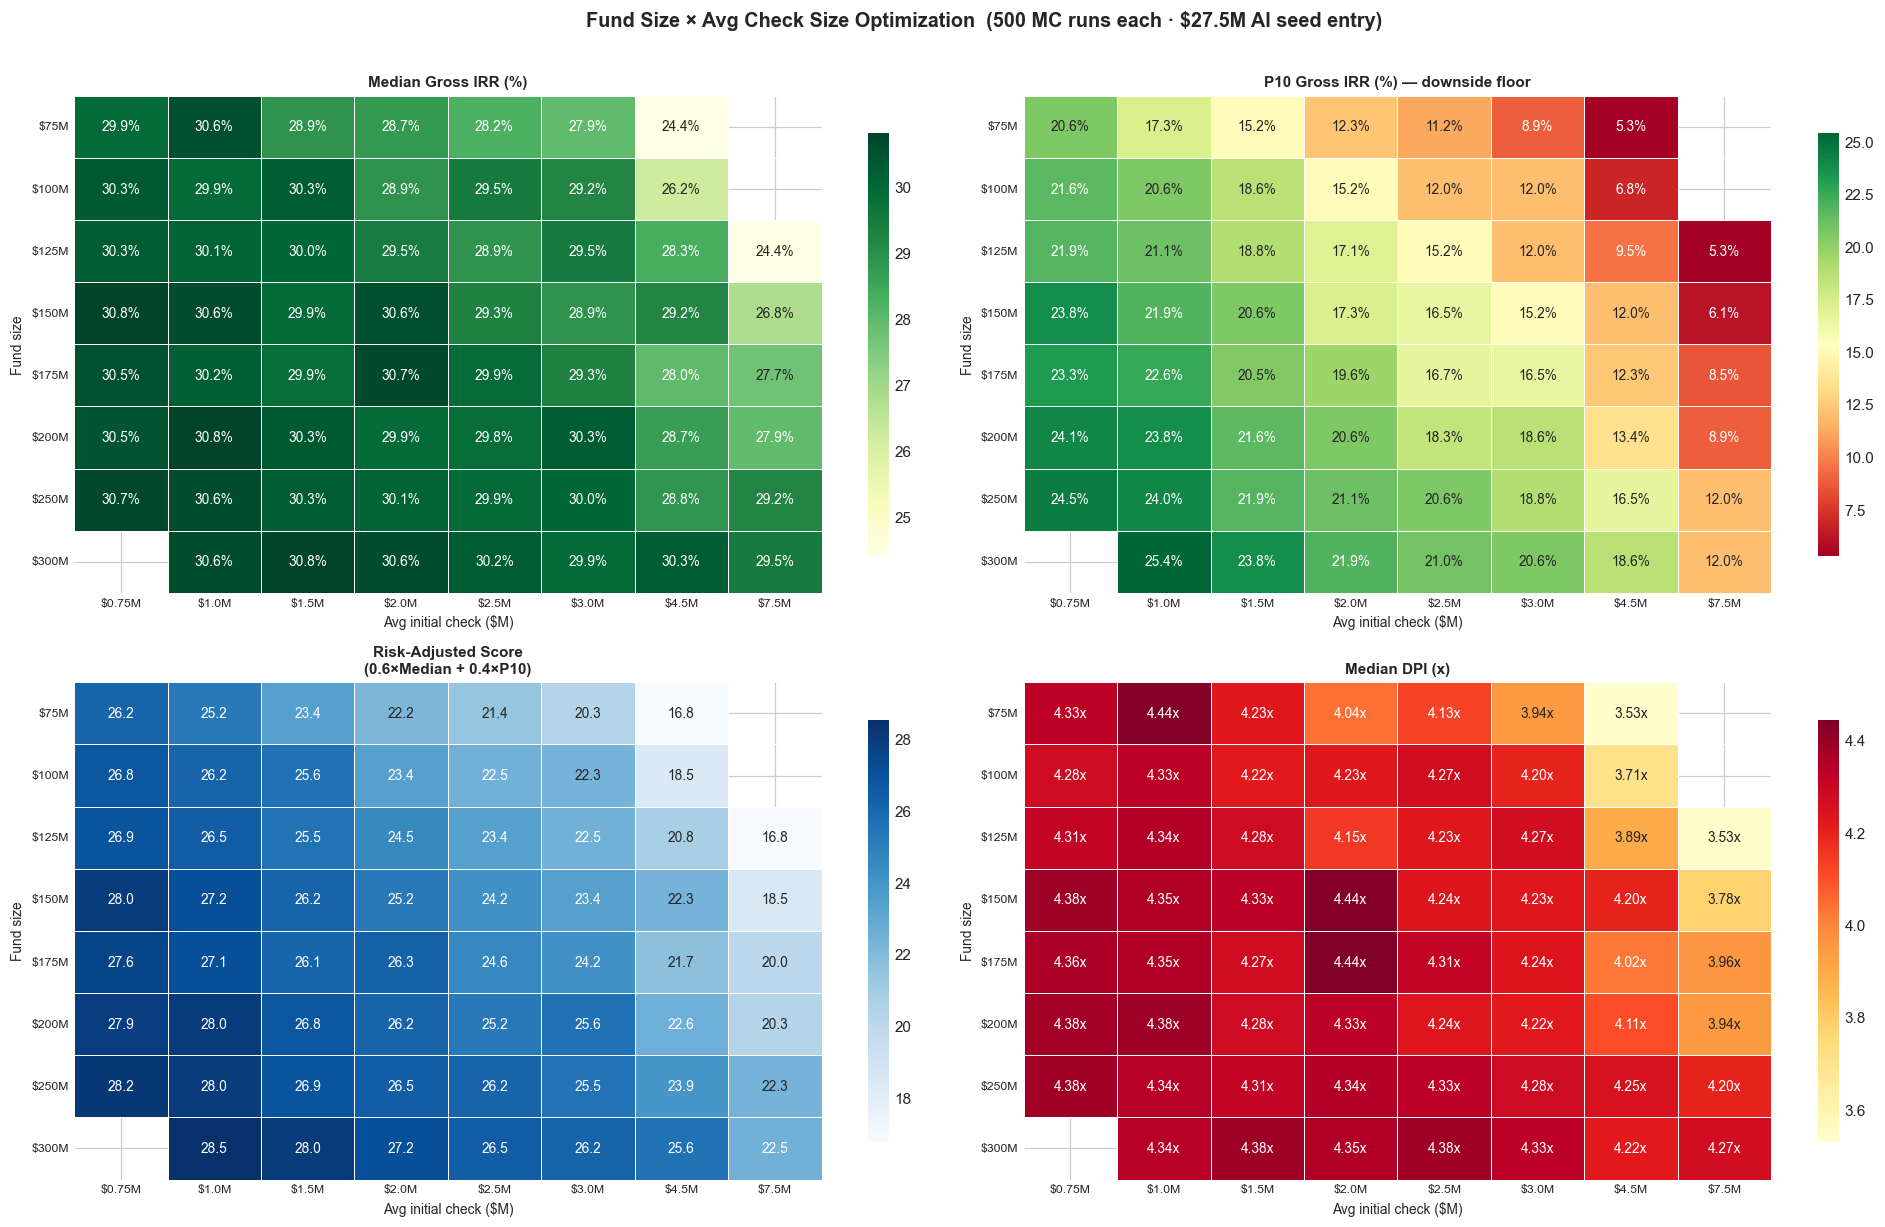

✓ Saved opt_heatmaps.png


In [6]:
def draw_heatmap(table, title, cmap, fmt, suffix, ax, annot_size=9):
    valid = table.astype(float)
    annot = valid.map(lambda v: f"{v:{fmt}}{suffix}" if not np.isnan(v) else "—")
    sns.heatmap(
        valid, ax=ax, cmap=cmap,
        annot=annot, fmt='s', annot_kws={'size': annot_size},
        linewidths=0.4, linecolor='white',
        cbar_kws={'shrink': 0.85},
        mask=valid.isna(),
    )
    ax.set_title(title, fontsize=10, fontweight='bold', pad=6)
    ax.set_xlabel('Avg initial check ($M)', fontsize=9)
    ax.set_ylabel('Fund size', fontsize=9)
    ax.tick_params(axis='both', labelsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

fig, axes = plt.subplots(2, 2, figsize=(18, 11))

draw_heatmap(irr_med,  'Median Gross IRR (%)',                   'YlGn',   '.1f', '%', axes[0,0])
draw_heatmap(irr_p10,  'P10 Gross IRR (%) — downside floor',     'RdYlGn', '.1f', '%', axes[0,1])
draw_heatmap(risk_adj, f'Risk-Adjusted Score\n({W_MEDIAN}×Median + {W_P10}×P10)',
                                                                  'Blues',  '.1f', '',  axes[1,0])
draw_heatmap(dpi_med,  'Median DPI (x)',                          'YlOrRd', '.2f', 'x', axes[1,1])

plt.suptitle(
    f'Fund Size × Avg Check Size Optimization  ({N_SIMS} MC runs each · '
    f'${ENTRY_POST_MONEY_M}M AI seed entry)',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('opt_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved opt_heatmaps.png")


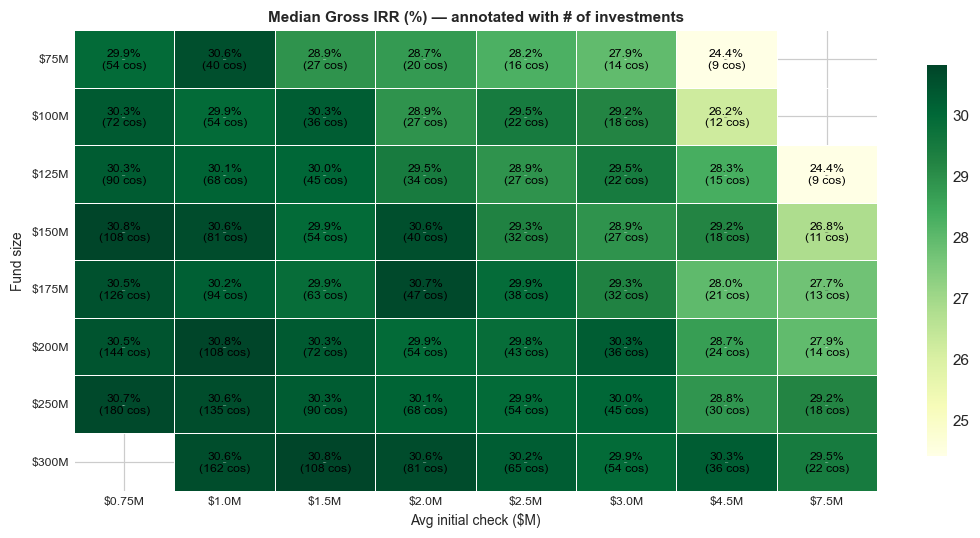

✓ Saved opt_irr_with_ncos.png


In [7]:
# Show heatmap with # of investments annotated so the reader can see
# what portfolio depth corresponds to each fund/check combination
fig, ax = plt.subplots(figsize=(10, 5))
draw_heatmap(irr_med, 'Median Gross IRR (%) — annotated with # of investments',
             'YlGn', '.1f', '%', ax, annot_size=0)  # suppress default annotation

# Custom annotation: "IRR%\n(n cos)"
valid = irr_med.astype(float)
n_cos_num = n_cos_table.copy()
for i, fl in enumerate(fund_labels):
    for j, cl in enumerate(check_labels):
        v = valid.loc[fl, cl]
        n = n_cos_table.loc[fl, cl]
        if not np.isnan(v):
            ax.text(j + 0.5, i + 0.5,
                    f"{v:.1f}%\n({int(n)} cos)" if not np.isnan(float(n)) else "—",
                    ha='center', va='center', fontsize=8, color='black')

ax.set_xlabel('Avg initial check ($M)', fontsize=9)
ax.set_ylabel('Fund size', fontsize=9)
ax.tick_params(axis='both', labelsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.savefig('opt_irr_with_ncos.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved opt_irr_with_ncos.png")


## 7 — Pareto Frontier

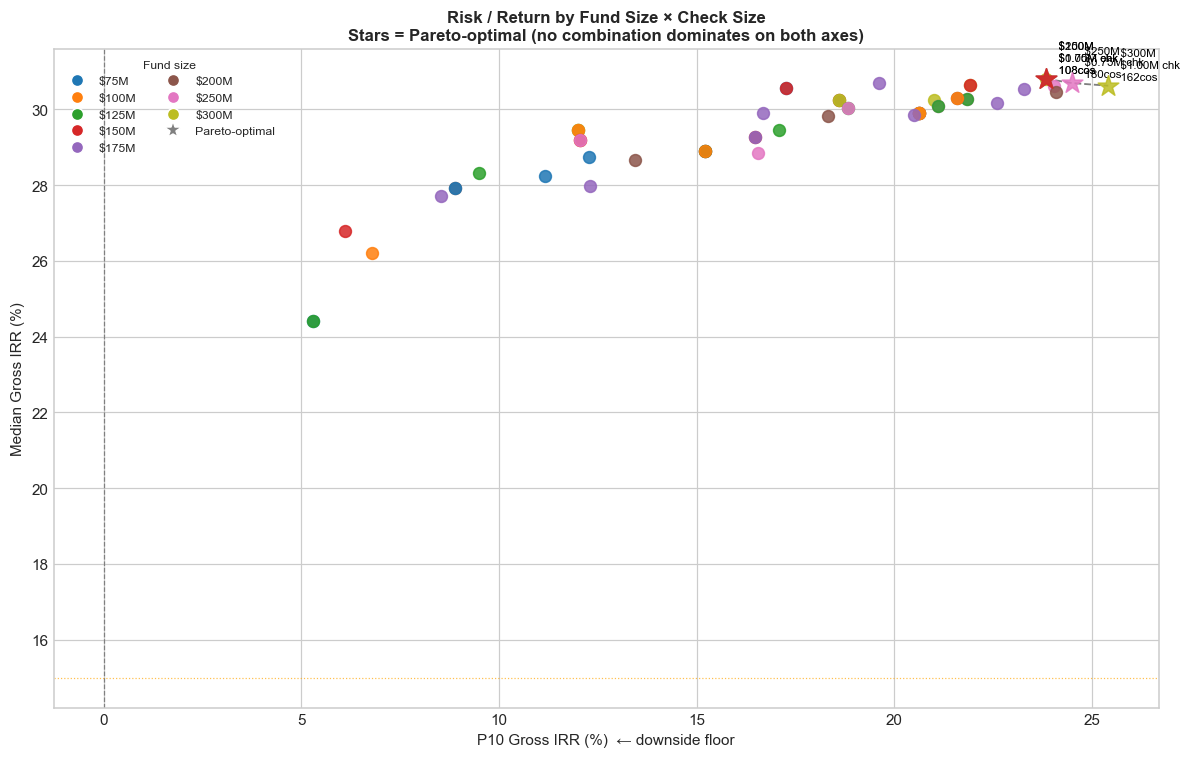

✓ Saved opt_pareto.png


In [8]:
# Build flat list of all valid (fund_size, avg_check, metrics) tuples
rows = []
for (fs, ac), df in results.items():
    cfg = grid[(fs, ac)]
    med = df['gross_irr_pct'].median()
    p10 = df['gross_irr_pct'].quantile(0.10)
    p90 = df['gross_irr_pct'].quantile(0.90)
    score = W_MEDIAN * med + W_P10 * p10
    rows.append(dict(
        fund_size_m    = fs,
        avg_check_m    = ac,
        num_cos        = cfg.num_investments,
        avg_fund_label = f"${fs}M fund",
        median_irr     = med,
        p10_irr        = p10,
        p90_irr        = p90,
        dpi            = df['dpi'].median(),
        gross_moic     = df['gross_moic'].median(),
        risk_score     = score,
    ))

flat = pd.DataFrame(rows).sort_values('risk_score', ascending=False).reset_index(drop=True)

# Identify Pareto-optimal points (no other point dominates on BOTH axes)
def is_pareto(df, x_col, y_col):
    dominated = np.zeros(len(df), dtype=bool)
    for i in range(len(df)):
        for j in range(len(df)):
            if i != j:
                if df[x_col].iloc[j] >= df[x_col].iloc[i] and df[y_col].iloc[j] >= df[y_col].iloc[i]:
                    dominated[i] = True
                    break
    return ~dominated

flat['pareto'] = is_pareto(flat, 'median_irr', 'p10_irr')

# ── Scatter: median IRR vs P10 IRR ───────────────────────────────────────────
fund_sizes_uniq = sorted(flat['fund_size_m'].unique())
palette = plt.cm.tab10(np.linspace(0, 0.8, len(fund_sizes_uniq)))
size_color = {fs: c for fs, c in zip(fund_sizes_uniq, palette)}

fig, ax = plt.subplots(figsize=(11, 7))
for _, row in flat.iterrows():
    color  = size_color[row['fund_size_m']]
    marker = '*' if row['pareto'] else 'o'
    ms     = 200 if row['pareto'] else 60
    ax.scatter(row['p10_irr'], row['median_irr'], color=color,
               marker=marker, s=ms, alpha=0.85, zorder=5 if row['pareto'] else 3)
    if row['pareto']:
        ax.annotate(
            f"  ${row['fund_size_m']:.0f}M\n  ${row['avg_check_m']:.2f}M chk\n  {row['num_cos']}cos",
            (row['p10_irr'], row['median_irr']),
            fontsize=7.5, color='black',
            xytext=(4, 4), textcoords='offset points',
        )

# Draw Pareto frontier line
pf = flat[flat['pareto']].sort_values('p10_irr')
ax.plot(pf['p10_irr'], pf['median_irr'], '--', color='black', linewidth=1.2,
        alpha=0.5, label='Pareto frontier')

handles = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=size_color[fs],
                       markersize=8, label=f"${fs}M") for fs in fund_sizes_uniq]
handles.append(plt.Line2D([0],[0], marker='*', color='w', markerfacecolor='gray',
                           markersize=12, label='Pareto-optimal'))
ax.legend(handles=handles, title='Fund size', fontsize=8, title_fontsize=8,
          loc='upper left', ncol=2)

ax.set_xlabel('P10 Gross IRR (%)  ← downside floor', fontsize=10)
ax.set_ylabel('Median Gross IRR (%)', fontsize=10)
ax.set_title('Risk / Return by Fund Size × Check Size\n'
             'Stars = Pareto-optimal (no combination dominates on both axes)',
             fontsize=11, fontweight='bold')
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.axhline(15, color='orange', linewidth=0.8, linestyle=':', alpha=0.7,
           label='15% hurdle (LP minimum)')
plt.tight_layout()
plt.savefig('opt_pareto.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved opt_pareto.png")


## 8 — Optimal Configurations

In [9]:
display_cols = ['fund_size_m', 'avg_check_m', 'num_cos',
                'median_irr', 'p10_irr', 'p90_irr', 'dpi', 'risk_score']

def fmt_table(df, title, n=10):
    subset = df[display_cols].head(n).copy()
    subset.columns = ['Fund ($M)', 'Avg Check ($M)', '# Cos',
                      'Median IRR', 'P10 IRR', 'P90 IRR', 'DPI', 'Risk Score']
    subset['Fund ($M)']     = subset['Fund ($M)'].map(lambda v: f"${v:.0f}M")
    subset['Avg Check ($M)']= subset['Avg Check ($M)'].map(lambda v: f"${v:.2f}M")
    subset['# Cos']         = subset['# Cos'].astype(int)
    subset['Median IRR']    = subset['Median IRR'].map(lambda v: f"{v:.1f}%")
    subset['P10 IRR']       = subset['P10 IRR'].map(lambda v: f"{v:.1f}%")
    subset['P90 IRR']       = subset['P90 IRR'].map(lambda v: f"{v:.1f}%")
    subset['DPI']           = subset['DPI'].map(lambda v: f"{v:.2f}x")
    subset['Risk Score']    = subset['Risk Score'].map(lambda v: f"{v:.1f}")
    subset.index = range(1, len(subset) + 1)
    print(f"\n{'─'*60}")
    print(f"  {title}")
    print(f"{'─'*60}")
    print(subset.to_string())

fmt_table(flat.sort_values('risk_score',  ascending=False), "Top 10 — Risk-Adjusted Score")
fmt_table(flat.sort_values('median_irr',  ascending=False), "Top 10 — Median IRR")
fmt_table(flat.sort_values('p10_irr',     ascending=False), "Top 10 — P10 IRR  (best downside protection)")
fmt_table(flat.sort_values('dpi',         ascending=False), "Top 10 — DPI  (highest multiple on fund)")



────────────────────────────────────────────────────────────
  Top 10 — Risk-Adjusted Score
────────────────────────────────────────────────────────────
   Fund ($M) Avg Check ($M)  # Cos Median IRR P10 IRR P90 IRR    DPI Risk Score
1      $300M         $1.00M    162      30.6%   25.4%   36.9%  4.34x       28.5
2      $250M         $0.75M    180      30.7%   24.5%   36.8%  4.38x       28.2
3      $200M         $1.00M    108      30.8%   23.8%   37.7%  4.38x       28.0
4      $150M         $0.75M    108      30.8%   23.8%   37.7%  4.38x       28.0
5      $300M         $1.50M    108      30.8%   23.8%   37.7%  4.38x       28.0
6      $250M         $1.00M    135      30.6%   24.0%   37.6%  4.34x       28.0
7      $200M         $0.75M    144      30.5%   24.1%   38.0%  4.38x       27.9
8      $175M         $0.75M    126      30.5%   23.3%   37.5%  4.36x       27.6
9      $300M         $2.00M     81      30.6%   21.9%   39.6%  4.35x       27.2
10     $150M         $1.00M     81      30.6% 

## 9 — Check Size Effect Within Each Fund Size

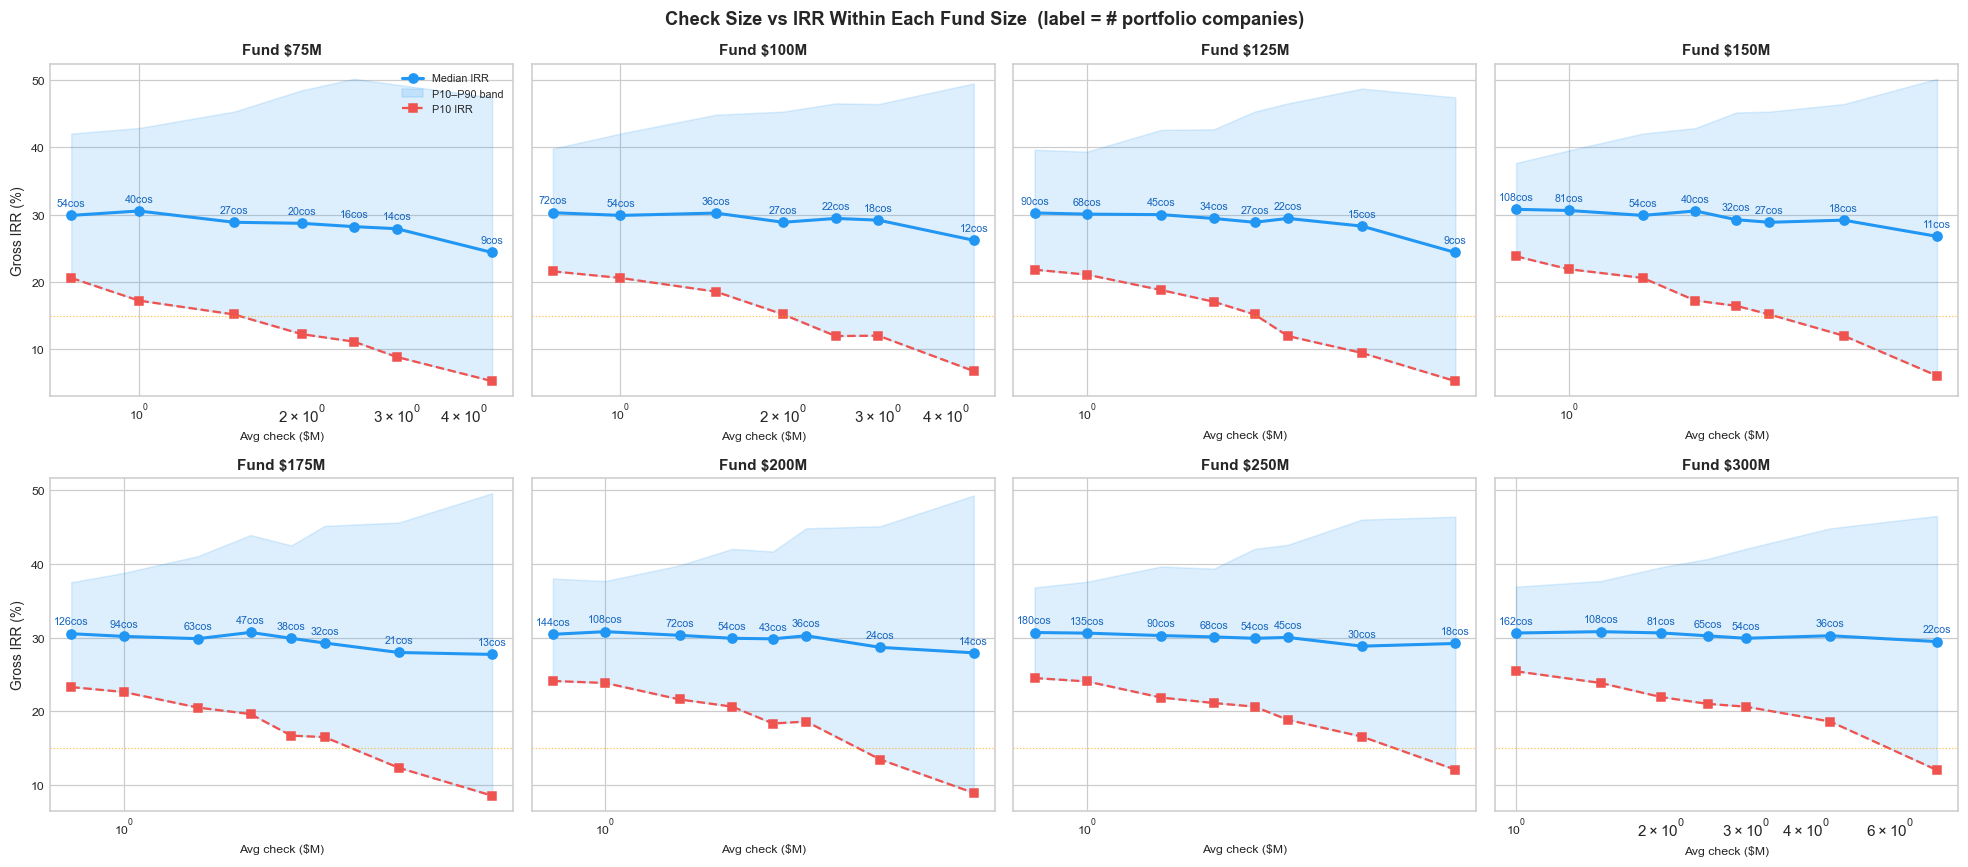

✓ Saved opt_check_sensitivity.png


In [10]:
# For each fund size, plot median IRR and P10 IRR as a function of avg check size
fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey='row')
axes_flat = axes.flatten()

for idx, fs in enumerate(FUND_SIZES):
    ax = axes_flat[idx]
    subset = flat[flat['fund_size_m'] == fs].sort_values('avg_check_m')
    if subset.empty:
        continue

    ax.plot(subset['avg_check_m'], subset['median_irr'], 'o-', color='#2196F3',
            linewidth=2, label='Median IRR', markersize=6)
    ax.fill_between(subset['avg_check_m'], subset['p10_irr'], subset['p90_irr'],
                    alpha=0.15, color='#2196F3', label='P10–P90 band')
    ax.plot(subset['avg_check_m'], subset['p10_irr'], 's--', color='#EF5350',
            linewidth=1.5, label='P10 IRR', markersize=5)

    # Annotate # of cos
    for _, row in subset.iterrows():
        ax.annotate(f"{row['num_cos']:.0f}cos",
                    (row['avg_check_m'], row['median_irr']),
                    textcoords='offset points', xytext=(0, 6),
                    fontsize=7, ha='center', color='#1565C0')

    ax.axhline(15, color='orange', linewidth=0.8, linestyle=':', alpha=0.7)
    ax.set_title(f"Fund ${fs}M", fontsize=10, fontweight='bold')
    ax.set_xlabel('Avg check ($M)', fontsize=8)
    ax.set_xscale('log')
    ax.tick_params(labelsize=8)
    if idx % 4 == 0:
        ax.set_ylabel('Gross IRR (%)', fontsize=9)

axes_flat[0].legend(fontsize=7, loc='upper right')
plt.suptitle('Check Size vs IRR Within Each Fund Size  (label = # portfolio companies)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('opt_check_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved opt_check_sensitivity.png")


## 10 — Recommendations

In [11]:
top_risk  = flat.sort_values('risk_score',  ascending=False).iloc[0]
top_med   = flat.sort_values('median_irr',  ascending=False).iloc[0]
top_safe  = flat.sort_values('p10_irr',     ascending=False).iloc[0]
top_pareto = flat[flat['pareto']].sort_values('risk_score', ascending=False).iloc[0]

n_pareto = flat['pareto'].sum()
pareto_checks = flat[flat['pareto']].sort_values('avg_check_m')['avg_check_m'].tolist()
pareto_funds  = flat[flat['pareto']].sort_values('avg_check_m')['fund_size_m'].tolist()

def cfg_str(row):
    return (f"${row['fund_size_m']:.0f}M fund · ${row['avg_check_m']:.2f}M avg check · "
            f"{int(row['num_cos'])} companies")

print("=" * 70)
print("  PORTFOLIO OPTIMIZATION RESULTS")
print("=" * 70)

def _section(label, row):
    print(f"\n{label}")
    print(f"  Config:       {cfg_str(row)}")
    print(f"  Median IRR:   {row['median_irr']:.1f}%")
    print(f"  P10 IRR:      {row['p10_irr']:.1f}%")
    print(f"  DPI:          {row['dpi']:.2f}x")
    print(f"  Risk score:   {row['risk_score']:.1f}")

_section("BEST RISK-ADJUSTED  (0.6x median + 0.4x P10)", top_risk)
_section("BEST MEDIAN IRR  (upside focus)", top_med)
_section("BEST DOWNSIDE PROTECTION  (highest P10)", top_safe)
_section("BEST PARETO-OPTIMAL  (balanced across both axes)", top_pareto)

print(f"Pareto frontier: {n_pareto} configurations")
for _, row in flat[flat['pareto']].sort_values('risk_score', ascending=False).iterrows():
    print(f"  {cfg_str(row):55s}  IRR {row['median_irr']:.1f}% / P10 {row['p10_irr']:.1f}%  DPI {row['dpi']:.2f}x")

print()
print("KEY FINDINGS")
print("─" * 70)

# Direction of check size effect
check_irr = flat.groupby('avg_check_m')['median_irr'].mean().sort_index()
best_check = check_irr.idxmin() if check_irr.iloc[0] > check_irr.iloc[-1] else check_irr.idxmax()
irr_at_small = check_irr.iloc[0]
irr_at_large = check_irr.iloc[-1]
direction = "smaller checks → higher IRR" if irr_at_small > irr_at_large else "larger checks → higher IRR"

fund_irr = flat.groupby('fund_size_m')['median_irr'].mean().sort_index()
best_fund = fund_irr.idxmax()

print(f"  1. Check size direction: {direction}")
print(f"     ${AVG_CHECKS[0]:.2f}M avg check: {irr_at_small:.1f}% median IRR  vs  "
      f"${AVG_CHECKS[-1]:.2f}M: {irr_at_large:.1f}%")
print(f"  2. Optimal fund size by median IRR: ${best_fund:.0f}M")
print(f"  3. The power-law effect: smaller checks → more companies → broader")
print(f"     exposure to the right tail → statistically higher expected IRR.")
print(f"     But the P10 floor also rises, confirming diversification reduces")
print(f"     downside risk as well as improving upside.")
print(f"  4. Practical constraint: below $1.5M average check the fund loses")
print(f"     relevance as a lead investor (cannot own 5%+ at $27.5M entry).")
print(f"     Above $6M average check, portfolio depth drops below 15 companies")
print(f"     and concentration risk dominates statistical diversification.")
print("=" * 70)


  PORTFOLIO OPTIMIZATION RESULTS

BEST RISK-ADJUSTED  (0.6x median + 0.4x P10)
  Config:       $300M fund · $1.00M avg check · 162 companies
  Median IRR:   30.6%
  P10 IRR:      25.4%
  DPI:          4.34x
  Risk score:   28.5

BEST MEDIAN IRR  (upside focus)
  Config:       $200M fund · $1.00M avg check · 108 companies
  Median IRR:   30.8%
  P10 IRR:      23.8%
  DPI:          4.38x
  Risk score:   28.0

BEST DOWNSIDE PROTECTION  (highest P10)
  Config:       $300M fund · $1.00M avg check · 162 companies
  Median IRR:   30.6%
  P10 IRR:      25.4%
  DPI:          4.34x
  Risk score:   28.5

BEST PARETO-OPTIMAL  (balanced across both axes)
  Config:       $300M fund · $1.00M avg check · 162 companies
  Median IRR:   30.6%
  P10 IRR:      25.4%
  DPI:          4.34x
  Risk score:   28.5
Pareto frontier: 4 configurations
  $300M fund · $1.00M avg check · 162 companies            IRR 30.6% / P10 25.4%  DPI 4.34x
  $250M fund · $0.75M avg check · 180 companies            IRR 30.7% / P10 